# Adult Income Classification

This notebook builds a tree-based classification pipeline for the UCI Adult dataset. The goal is to predict whether a person earns more than 50K per year using demographic and employment-related features.


In [21]:
import sys
sys.path.append("..")
from utils.utils import * 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline
from scipy.stats import randint, uniform, loguniform
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 


## Data Loading

Load the Adult dataset from UCI, separate features and target, and convert the dataset-specific `?` placeholders into missing values.


In [22]:
adult = fetch_ucirepo(id=2) 

X = adult.data.features 
y = adult.data.targets.squeeze()
X = X.replace("?", np.nan)

## Full Dataset Inspection

Inspect the complete dataset to understand the feature schema, missing values, categorical distributions, numerical distributions, and target class balance before creating the train-test split.


### Initial Feature Preview

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba


### Initial Target Preview

0    <=50K
1    <=50K
2    <=50K
3    <=50K
4    <=50K
Name: income, dtype: object

### Feature Missing-Value Check

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       46043 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      46033 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  47985 non-null  object
dtypes: int64(6), object(8)
memory usage: 5.2+ MB


### Target Schema Summary

<class 'pandas.core.series.Series'>
RangeIndex: 48842 entries, 0 to 48841
Series name: income
Non-Null Count  Dtype 
--------------  ----- 
48842 non-null  object
dtypes: object(1)
memory usage: 381.7+ KB


### Feature Distributions

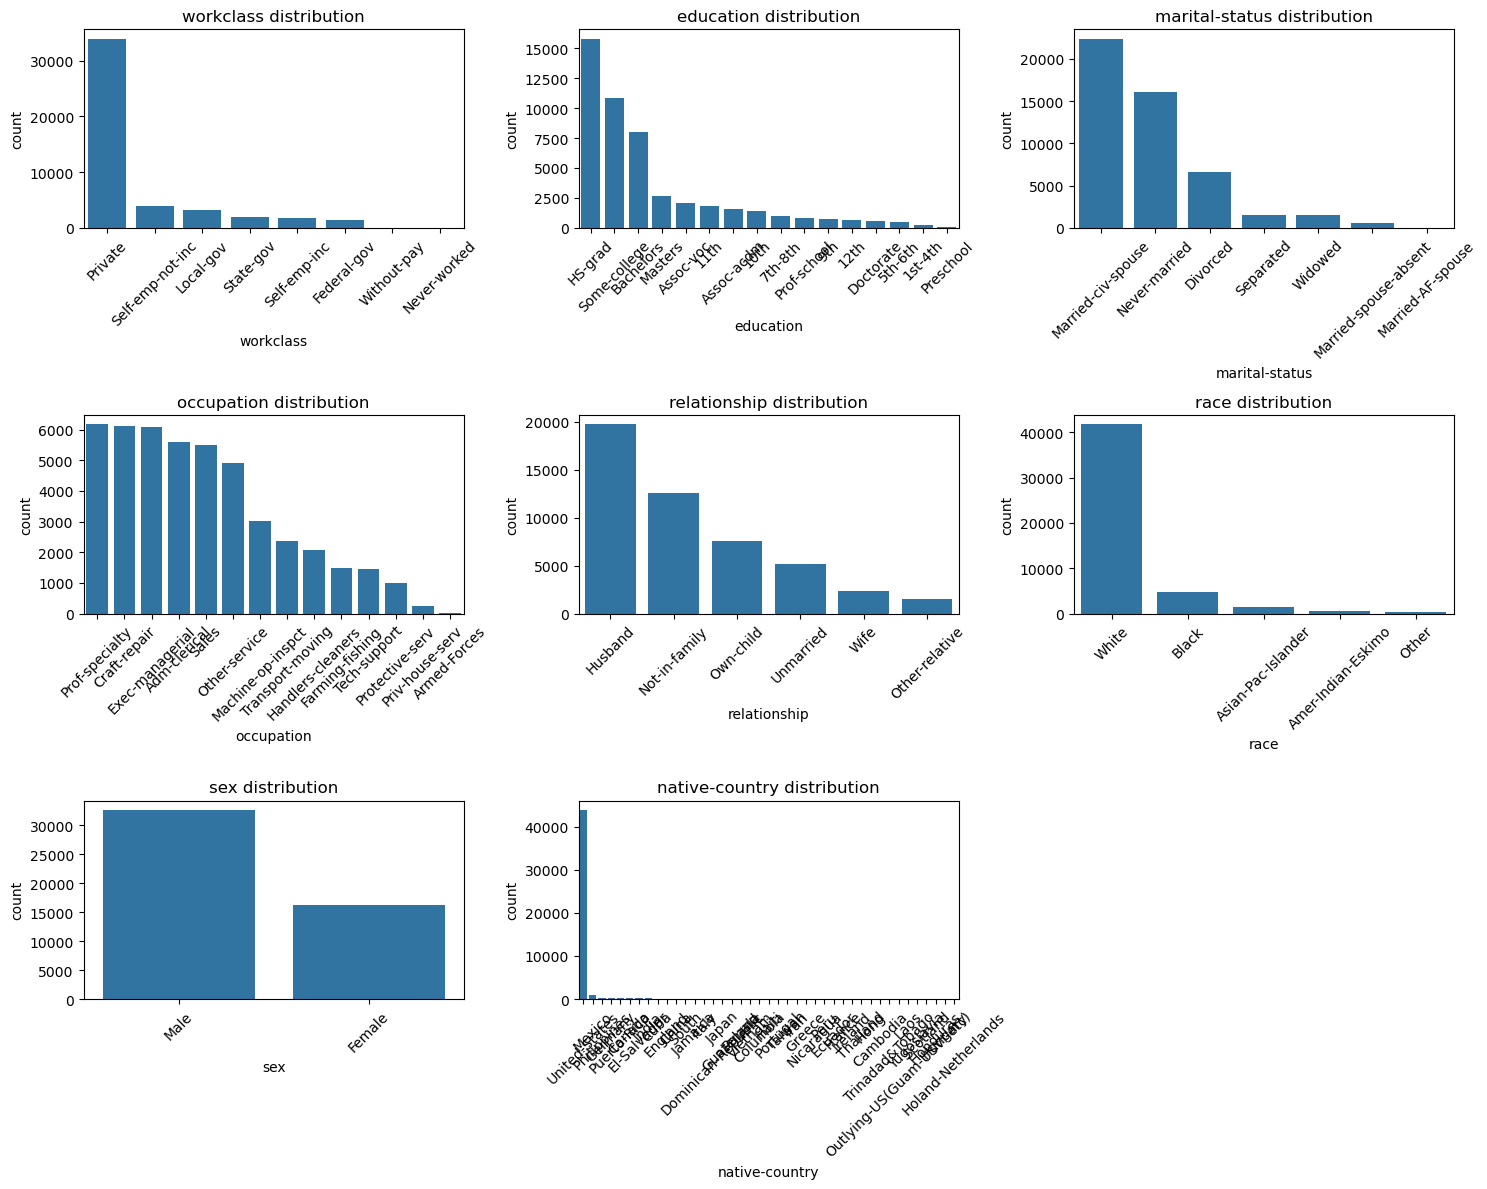

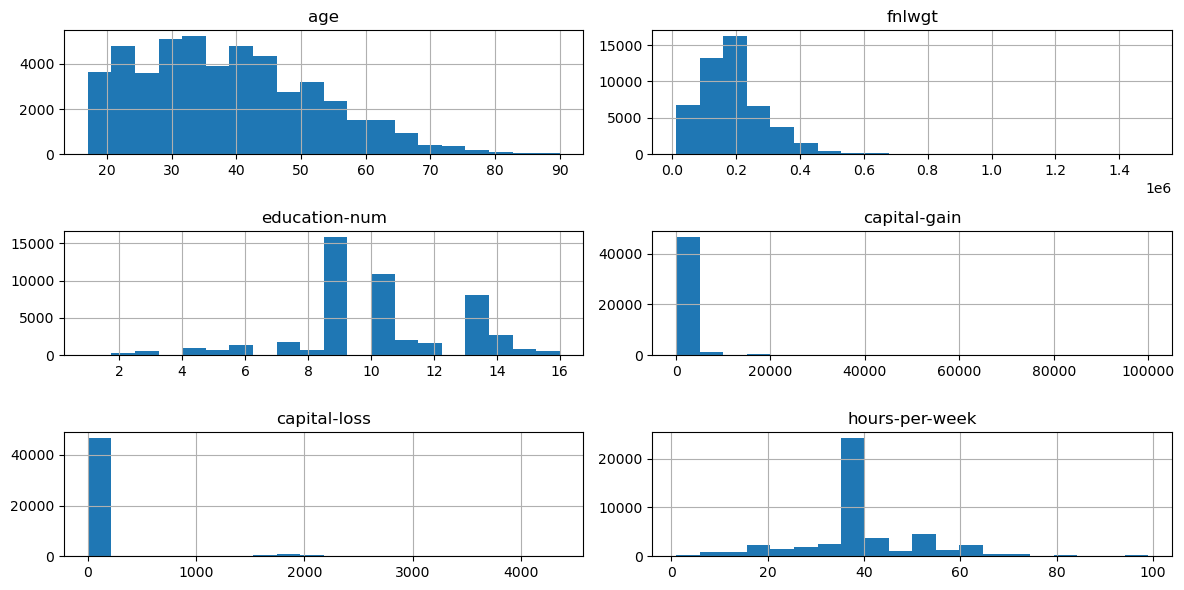

### Class Distribution

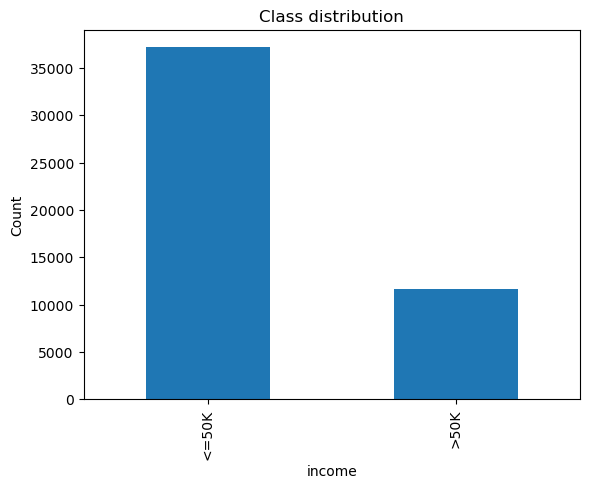

In [23]:
y[y == "<=50K."] = "<=50K"
y[y == ">50K."] = ">50K"
display(Markdown("### Initial Feature Preview"))
display(X.head())
display(Markdown("### Initial Target Preview"))
display(y.head())
display(Markdown("### Feature Missing-Value Check"))
display(X.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y.isnull().sum())
display(Markdown("### Feature Schema Summary"))
X.info()
display(Markdown("### Target Schema Summary"))
y.info()
display(Markdown("### Feature Distributions"))
X_cat = X.select_dtypes(include=["object", "category"])
X_num = X.select_dtypes(include=["float64", "int64"])
plot_class_distribution(X_cat)
X_num.hist(figsize=(12,6), bins=20)
plt.tight_layout()
plt.show()
display(Markdown("### Class Distribution"))
y.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Training Data Inspection

Create a stratified train-test split and inspect only the training data used for preprocessing, model selection, and cross-validation.


### Initial Feature Preview

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
34495,37,Private,193106,Bachelors,13,Never-married,Sales,Not-in-family,White,Female,0,0,30,United-States
18591,56,Self-emp-inc,216636,12th,8,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1651,40,United-States
12562,53,Private,126977,HS-grad,9,Separated,Craft-repair,Not-in-family,White,Male,0,0,35,United-States
552,72,Private,205343,11th,7,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States
3479,46,State-gov,106705,Masters,14,Never-married,Exec-managerial,Not-in-family,White,Female,0,0,38,United-States


### Initial Target Preview

34495    <=50K
18591    <=50K
12562    <=50K
552      <=50K
3479     <=50K
Name: income, dtype: object

### Feature Missing-Value Check

age                  0
workclass         2233
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2241
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     688
dtype: int64

### Target Missing-Value Check

np.int64(0)

### Feature Schema Summary

<class 'pandas.core.frame.DataFrame'>
Index: 39073 entries, 34495 to 42715
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             39073 non-null  int64 
 1   workclass       36840 non-null  object
 2   fnlwgt          39073 non-null  int64 
 3   education       39073 non-null  object
 4   education-num   39073 non-null  int64 
 5   marital-status  39073 non-null  object
 6   occupation      36832 non-null  object
 7   relationship    39073 non-null  object
 8   race            39073 non-null  object
 9   sex             39073 non-null  object
 10  capital-gain    39073 non-null  int64 
 11  capital-loss    39073 non-null  int64 
 12  hours-per-week  39073 non-null  int64 
 13  native-country  38385 non-null  object
dtypes: int64(6), object(8)
memory usage: 4.5+ MB


### Target Schema Summary

<class 'pandas.core.series.Series'>
Index: 39073 entries, 34495 to 42715
Series name: income
Non-Null Count  Dtype 
--------------  ----- 
39073 non-null  object
dtypes: object(1)
memory usage: 610.5+ KB


### Feature Distributions

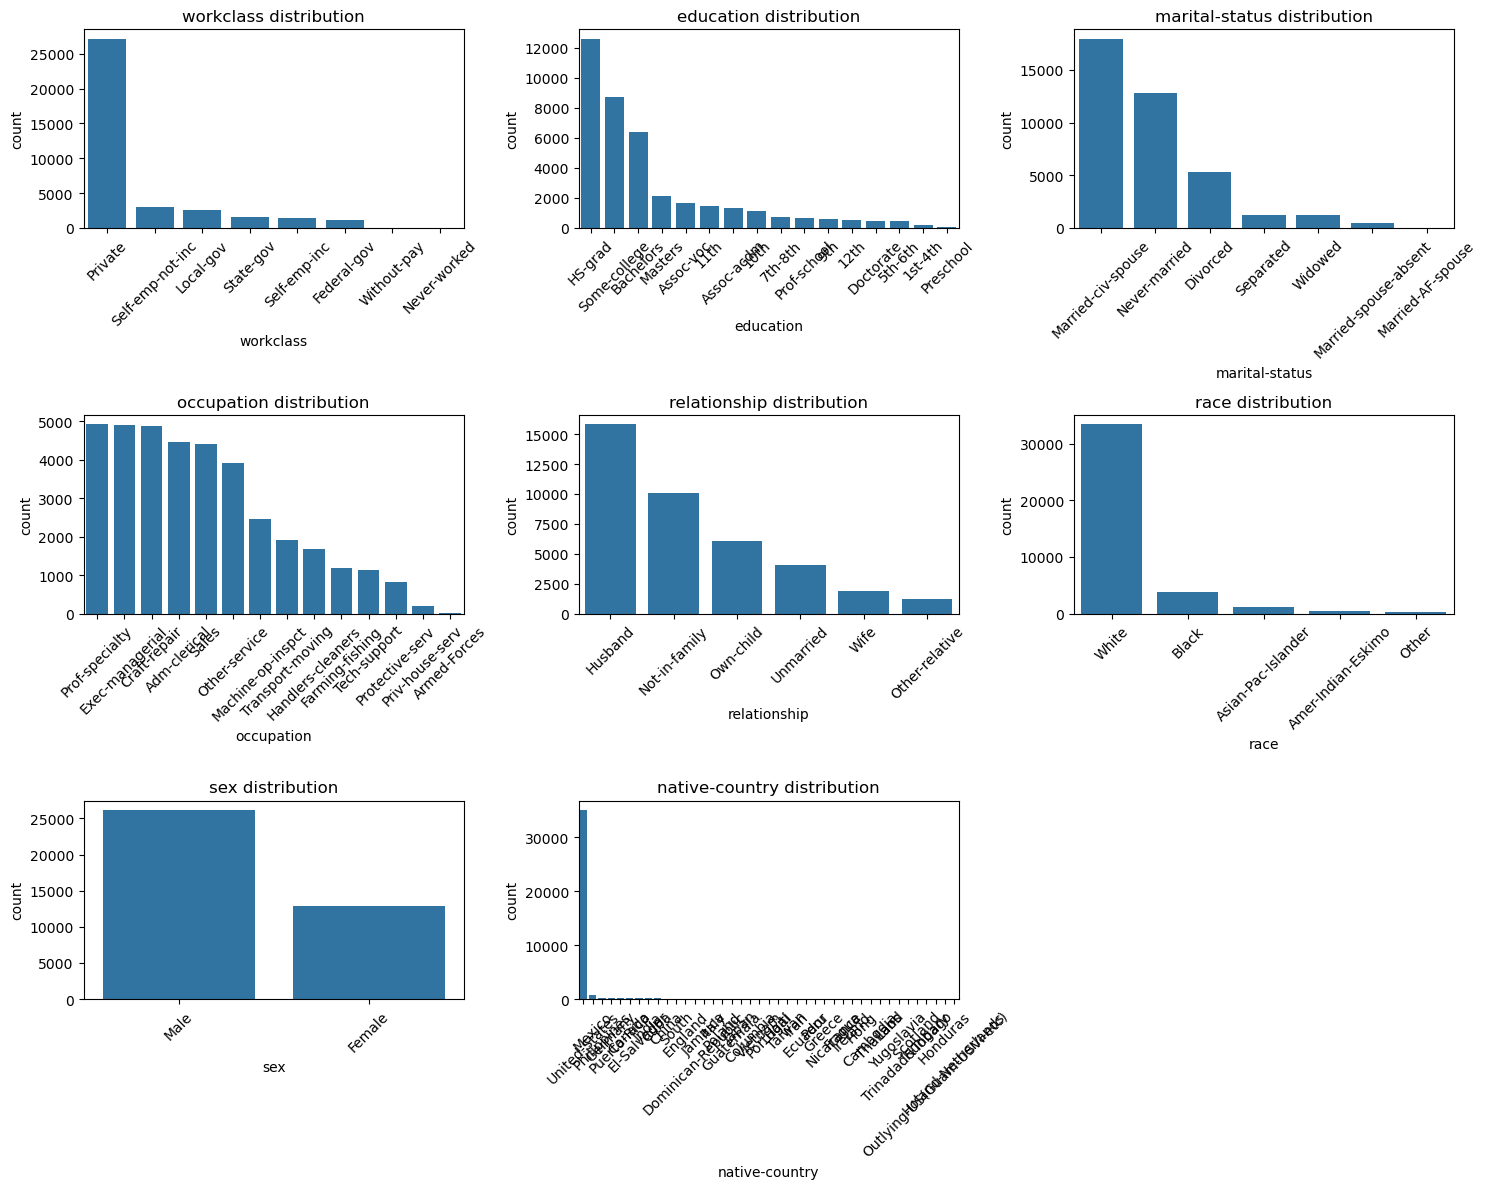

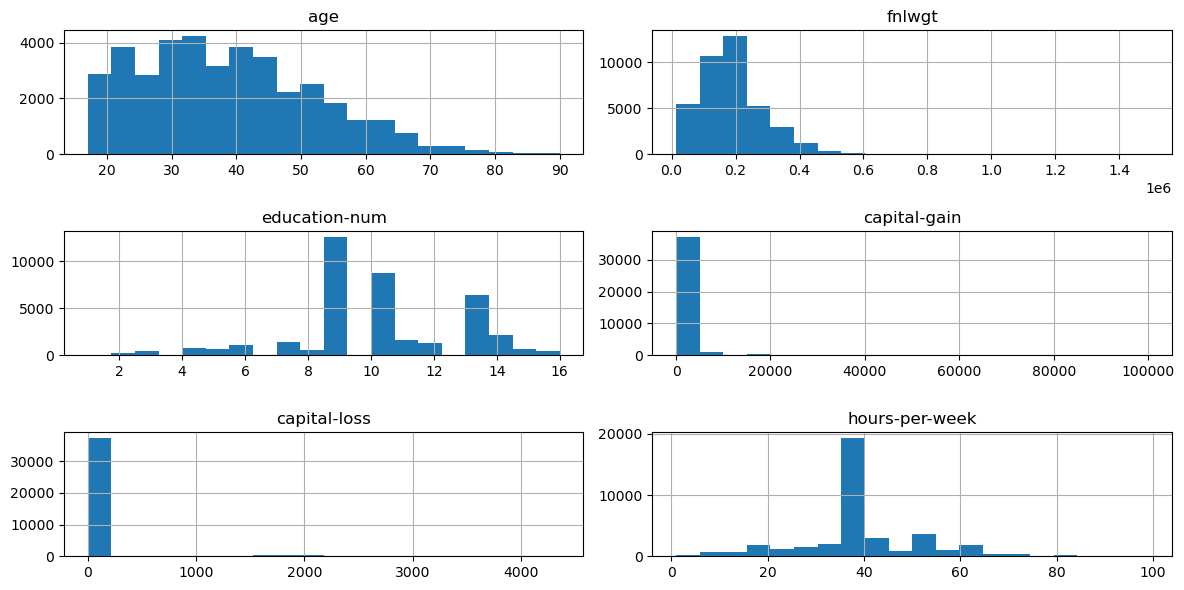

### Class Distribution

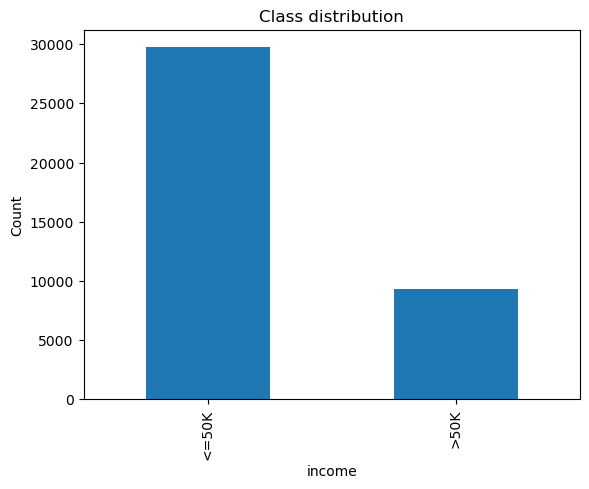

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

display(Markdown("### Initial Feature Preview"))
display(X_train.head())
display(Markdown("### Initial Target Preview"))
display(y_train.head())

display(Markdown("### Feature Missing-Value Check"))
display(X_train.isnull().sum())
display(Markdown("### Target Missing-Value Check"))
display(y_train.isnull().sum())

display(Markdown("### Feature Schema Summary"))
X_train.info()
display(Markdown("### Target Schema Summary"))
y_train.info()

display(Markdown("### Feature Distributions"))
X_cat = X_train.select_dtypes(include=["object", "category"])
X_num = X_train.select_dtypes(include=["float64", "int64"])

plot_class_distribution(X_cat)

X_num.hist(figsize=(12, 6), bins=20)
plt.tight_layout()
plt.show()

display(Markdown("### Class Distribution"))
y_train.value_counts().plot(kind="bar")
plt.ylabel("Count")
plt.title("Class distribution")
plt.show()

## Preprocessing

The target classes are imbalanced, so model selection uses `balanced_accuracy` with `StratifiedKFold`. Missing categorical values in `native-country`, `workclass`, and `occupation` are imputed with the most frequent value, categorical features are one-hot encoded, and numerical features are standardized inside the pipeline.


In [25]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore")
)

num_pipeline = make_pipeline(
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ("num", num_pipeline, X_num.columns),
    ("cat", cat_pipeline, X_cat.columns)
])

## Model Selection

Compare decision-tree, bagging, random-forest, and gradient-boosting classifiers with randomized hyperparameter search. Preprocessing is part of the pipeline so every cross-validation fold fits transformations only on its training split.


In [29]:
pipe = Pipeline([
    ("preprocessing", preprocessing),
    ("model", BaggingClassifier())
])

alphas = [0, 0.005, 0.01, 0.02, 0.05, 0.1]
depths = [3, 5, 8, 12, 20, None]
gb_depths = [2, 3, 4, 5]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
param_distributions = [
    {
        "model": [
            DecisionTreeClassifier(random_state=42, class_weight="balanced")
        ],
        "model__ccp_alpha": alphas,
        "model__max_depth": depths
    },
    {
        "model": [
            BaggingClassifier(
                estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
                random_state=42,
                n_jobs=-1
                )
            ],
        "model__n_estimators": randint(50, 401),
        "model__estimator__ccp_alpha": alphas,
        "model__estimator__max_depth": depths

    },
    {
        "model": [RandomForestClassifier(
            random_state=42,
            n_jobs=-1,
            class_weight="balanced"
        )],
        "model__n_estimators": randint(50, 401),
        "model__max_depth": depths

    },
    {
        "model": [GradientBoostingClassifier(
            random_state=42
        )],
        "model__n_estimators": randint(50, 501),
        "model__learning_rate": loguniform(0.01, 0.3),
        "model__max_depth": gb_depths
    }
]

rnd = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    scoring="balanced_accuracy",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    n_iter=40
)


rnd.fit(X_train, y_train)

best_model = rnd.best_estimator_
display(Markdown("### Cross-Validation Scores"))
display(rnd.cv_results_["mean_test_score"])
display(Markdown("### Best Selected Pipeline"))
best_model

### Cross-Validation Scores

array([0.82548379, 0.81298143, 0.75912671, 0.8127991 , 0.77818479,
       0.75912671, 0.7958681 , 0.78556021, 0.75912671, 0.77818479,
       0.78917098, 0.75565638, 0.77807784, 0.79781378, 0.82621451,
       0.78781777, 0.78875391, 0.75912671, 0.79674746, 0.77818479,
       0.77818479, 0.79616658, 0.79832107, 0.7981512 , 0.79728865,
       0.77072537, 0.76184183, 0.79251495, 0.78934786, 0.71476099,
       0.78235404, 0.77862162, 0.77818479, 0.77713396, 0.77877205,
       0.79779798, 0.77939779, 0.79483425, 0.75912671, 0.79053368])

### Best Selected Pipeline

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Evaluation

Evaluate the selected pipeline on the held-out test set with classification metrics and the confusion matrix.


Accuracy: 0.8307912785341386

Classification report:
              precision    recall  f1-score   support

       <=50K       0.94      0.84      0.88      7431
        >50K       0.61      0.82      0.70      2338

    accuracy                           0.83      9769
   macro avg       0.77      0.83      0.79      9769
weighted avg       0.86      0.83      0.84      9769

Confusion matrix:



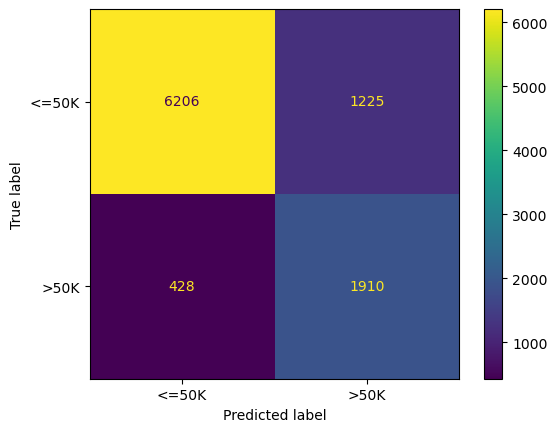

In [30]:
evaluate_classification(best_model, X_test, y_test)